# Chapter 4 — Gradient and Optimization

**Goals**

- Implement gradient descent for a 1-D quadratic from scratch.
- Watch what happens with too-small, just-right, and too-large learning rates.
- Run GD on a 2-D quadratic; visualize the trajectory.
- Verify an analytical gradient via finite differences.
- See the start of the chain that leads to linear regression in Chapter 6.

Pair with `docs/01_math_foundation.md` (Part C).

## 1. Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt

SEED = 42
rng = np.random.default_rng(SEED)
np.set_printoptions(precision=4, suppress=True)

## 2. The function we will minimize

Start with the simplest non-trivial example: $f(x) = (x - 3)^2 + 2$. The minimum is at $x = 3$ with $f(3) = 2$. The derivative is $f'(x) = 2(x - 3)$.

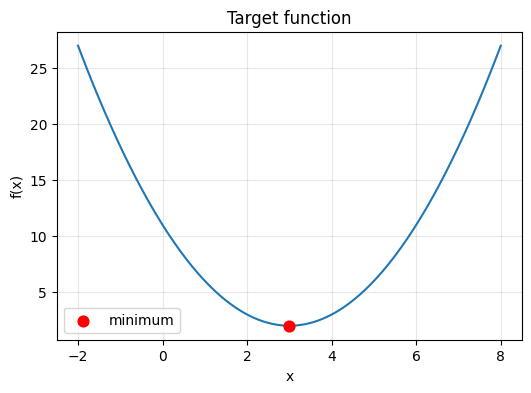

In [2]:
def f(x):
    return (x - 3.0) ** 2 + 2.0

def grad_f(x):
    return 2.0 * (x - 3.0)

xs = np.linspace(-2, 8, 200)
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(xs, f(xs))
ax.scatter([3], [f(3)], color='red', s=60, zorder=5, label='minimum')
ax.set_xlabel('x')
ax.set_ylabel('f(x)')
ax.set_title('Target function')
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

## 3. Gradient descent from scratch

In [3]:
def gradient_descent(grad, x0, lr, n_iters=50):
    """Run gradient descent and return the sequence of x values."""
    history = [x0]
    x = x0
    for _ in range(n_iters):
        x = x - lr * grad(x)
        history.append(x)
    return np.array(history)

history = gradient_descent(grad_f, x0=-1.0, lr=0.1, n_iters=30)
print(f'final x = {history[-1]:.4f}  (true min at 3)')
print(f'final f = {f(history[-1]):.4f}  (true min value 2)')

final x = 2.9950  (true min at 3)
final f = 2.0000  (true min value 2)


## 4. Mini-lab — three learning rates

Same function, three learning rates. Watch what happens.

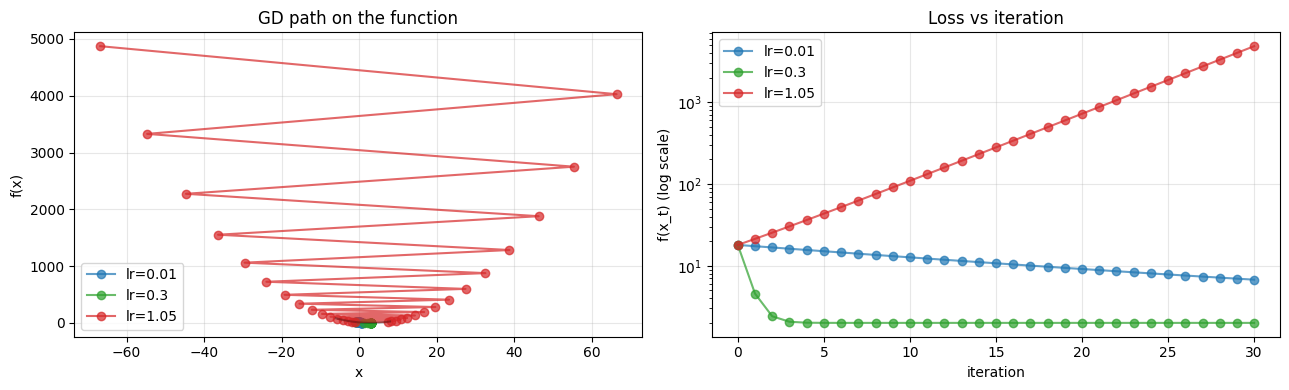

In [4]:
lrs = [0.01, 0.3, 1.05]      # too small, just right, too big
histories = [gradient_descent(grad_f, x0=-1.0, lr=lr, n_iters=30) for lr in lrs]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for lr, h, color in zip(lrs, histories, ['tab:blue', 'tab:green', 'tab:red']):
    axes[0].plot(h, f(h), 'o-', color=color, alpha=0.7, label=f'lr={lr}')
    axes[1].plot(range(len(h)), f(h), 'o-', color=color, alpha=0.7, label=f'lr={lr}')

xs = np.linspace(-6, 8, 200)
axes[0].plot(xs, f(xs), color='black', alpha=0.3)
axes[0].set_xlabel('x'); axes[0].set_ylabel('f(x)')
axes[0].set_title('GD path on the function')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].set_yscale('log')
axes[1].set_xlabel('iteration'); axes[1].set_ylabel('f(x_t) (log scale)')
axes[1].set_title('Loss vs iteration')
axes[1].legend(); axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Observation:**

- lr = 0.01 → tiny steps, slow descent but stable.
- lr = 0.30 → smooth, fast convergence.
- lr = 1.05 → each step overshoots, the trajectory diverges.

Try lr = 1.0 — convergence is at the edge. Try lr = 0.5 — fastest of the safe choices.

## 5. Two-variable example

$f(\mathbf{x}) = (x_1 - 2)^2 + 3(x_2 + 1)^2$ with $\nabla f(\mathbf{x}) = [2(x_1 - 2), \; 6(x_2 + 1)]^\top$.

final x = [ 2. -1.]   true min at [2, -1]


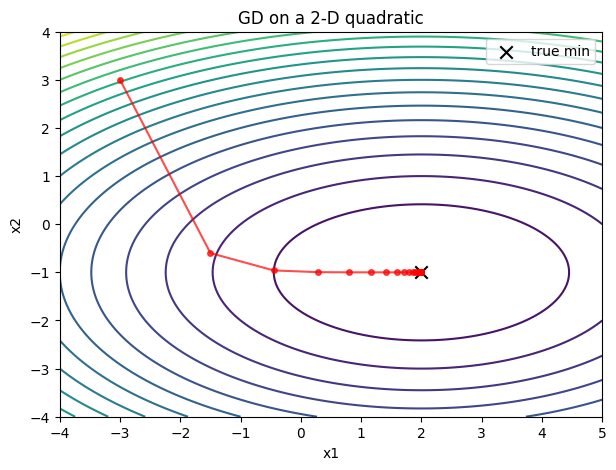

In [5]:
def f2(x):
    return (x[0] - 2.0) ** 2 + 3.0 * (x[1] + 1.0) ** 2

def grad_f2(x):
    return np.array([2.0 * (x[0] - 2.0), 6.0 * (x[1] + 1.0)])

x = np.array([-3.0, 3.0])
trajectory = [x.copy()]
for _ in range(40):
    x = x - 0.15 * grad_f2(x)
    trajectory.append(x.copy())
trajectory = np.array(trajectory)
print('final x =', trajectory[-1].round(4), '  true min at [2, -1]')

x1 = np.linspace(-4, 5, 200)
x2 = np.linspace(-4, 4, 200)
X1, X2 = np.meshgrid(x1, x2)
Z = (X1 - 2.0) ** 2 + 3.0 * (X2 + 1.0) ** 2

fig, ax = plt.subplots(figsize=(7, 5))
cs = ax.contour(X1, X2, Z, levels=20)
ax.plot(trajectory[:, 0], trajectory[:, 1], 'o-', color='red', markersize=4, alpha=0.7)
ax.scatter([2], [-1], color='black', s=80, marker='x', label='true min')
ax.set_xlabel('x1')
ax.set_ylabel('x2')
ax.set_title('GD on a 2-D quadratic')
ax.legend()
plt.show()

## 6. Gradient checking via finite differences

Useful sanity check for any hand-written gradient. Compare $\nabla f$ to the symmetric finite difference.

In [6]:
def numerical_gradient(f, x, h=1e-5):
    x = np.asarray(x, dtype=float)
    g = np.zeros_like(x)
    for i in range(x.size):
        e = np.zeros_like(x); e[i] = h
        g[i] = (f(x + e) - f(x - e)) / (2 * h)
    return g

x_test = np.array([0.5, -1.7])
g_analytic = grad_f2(x_test)
g_numeric  = numerical_gradient(f2, x_test)
print('analytic :', g_analytic)
print('numeric  :', g_numeric)
print('|diff|   :', np.linalg.norm(g_analytic - g_numeric))

analytic : [-3.  -4.2]
numeric  : [-3.  -4.2]
|diff|   : 5.761661162363123e-11


## 7. Preview — gradient descent for linear regression

We can already train a tiny linear regression. Generate noisy points around a line $y = 2x + 1$ and fit $\hat{y} = wx + b$ by minimizing MSE. Closed form exists, but we minimize via GD to make the connection.

learned w = 2.0121, b = 0.9658  (true 2.0, 1.0)


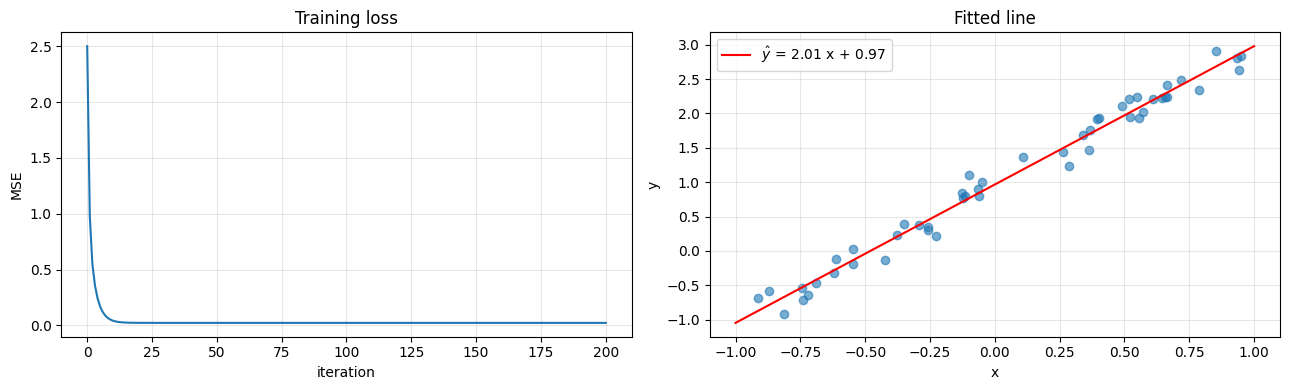

In [7]:
N = 50
x = rng.uniform(-1, 1, size=N)
y = 2.0 * x + 1.0 + rng.normal(0, 0.2, size=N)

def mse(w, b):
    return float(np.mean((y - (w * x + b)) ** 2))

def grad_mse(w, b):
    err = (w * x + b) - y
    return float(2 * np.mean(err * x)), float(2 * np.mean(err))

w, b = 0.0, 0.0
losses = [mse(w, b)]
for _ in range(200):
    gw, gb = grad_mse(w, b)
    w -= 0.3 * gw
    b -= 0.3 * gb
    losses.append(mse(w, b))

print(f'learned w = {w:.4f}, b = {b:.4f}  (true 2.0, 1.0)')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(losses)
axes[0].set_xlabel('iteration'); axes[0].set_ylabel('MSE'); axes[0].set_title('Training loss')
axes[0].grid(True, alpha=0.3)

xs = np.linspace(-1, 1, 100)
axes[1].scatter(x, y, alpha=0.6)
axes[1].plot(xs, w * xs + b, color='red', label=f'$\\hat y$ = {w:.2f} x + {b:.2f}')
axes[1].set_xlabel('x'); axes[1].set_ylabel('y')
axes[1].set_title('Fitted line')
axes[1].legend(); axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 8. Summary

- Gradient descent: `θ ← θ − η · ∇L(θ)`. That single rule trains nearly every model in this course.
- The learning rate is the most important knob. Too small wastes compute, too large diverges.
- Convex losses (linear regression's MSE) have a unique minimum that GD always finds.
- Gradient checking with finite differences is your friend when implementing gradients by hand.
- We just trained a tiny linear regression — that's a sneak peek at Chapter 6.

**Next:** `notebooks/chapter_03_ml_pipeline.ipynb` — the train / validate / test loop.

## Quick Check

1. Write the gradient-descent update rule in one line.
2. What is the effect of a learning rate that is too large? Too small?
3. What is the practical difference between batch GD, SGD, and mini-batch GD?
4. Why does momentum help on functions with elongated valleys?
5. What is gradient checking, and when should you use it?


## Further Reading

- Vũ Hữu Tiệp, *Machine Learning cơ bản* — Chương 12 (Gradient Descent).
- Sebastian Ruder, *An Overview of Gradient Descent Optimization Algorithms*.
- Goodfellow, Bengio, Courville, *Deep Learning*, Chapter 8.
